#**IMPORT LIBRARY & DATASET**

In [ ]:
import numpy as np
import pandas as pd
import gdown
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

In [ ]:
file_url = 'https://drive.google.com/uc?id=1fLTEhNXGRxJy3vVJ38FTbaT0IGRSZfEO'
output_file = 'P2P_Lending.csv'
gdown.download(file_url, output_file, quiet=False)
df = pd.read_csv(output_file)

Downloading...
From (original): https://drive.google.com/uc?id=1fLTEhNXGRxJy3vVJ38FTbaT0IGRSZfEO
From (redirected): https://drive.google.com/uc?id=1fLTEhNXGRxJy3vVJ38FTbaT0IGRSZfEO&confirm=t&uuid=0790b8ce-f065-4551-ba47-f442bee453c3
To: /content/P2P_Lending.csv
100%|██████████| 914M/914M [00:13<00:00, 66.2MB/s]


In [ ]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,logunemployment,loggdppercap,muni_points,muni_6m,logCPIUS,logloan_vol,FED_lag6,riskprem,loglvol_6m,issue_year
0,11875,11875,11875.0,36 months,0.1531,413.459990,C,C2,2 years,MORTGAGE,...,10.076684,8.792181,2.343903,2.357462,5.470159,13.270999,0.11,3.2075,12.679430,2012
1,11500,11500,11500.0,36 months,0.1849,418.590000,D,D2,1 year,OWN,...,10.076684,8.792181,2.343903,2.357462,5.470159,13.270999,0.11,3.2075,12.679430,2012
2,2300,2300,2300.0,36 months,0.0890,73.040001,A,A5,10+ years,RENT,...,10.076684,8.792181,2.343903,2.357462,5.470159,13.270999,0.11,3.2075,12.166292,2012
3,19600,19600,19600.0,36 months,0.1409,670.739990,B,B5,7 years,RENT,...,10.149370,8.812758,2.573472,2.691933,5.460810,11.981991,0.09,3.2150,12.166292,2012
4,3900,3900,3900.0,36 months,0.1311,131.620000,B,B4,7 years,RENT,...,10.149409,8.807574,2.559913,2.691933,5.469034,12.361687,0.09,3.2150,12.166292,2012


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1405497 entries, 0 to 1405496
Data columns (total 88 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   loan_amnt                   1405497 non-null  int64  
 1   funded_amnt                 1405497 non-null  int64  
 2   funded_amnt_inv             1405497 non-null  float64
 3   term                        1405497 non-null  object 
 4   int_rate                    1405497 non-null  float64
 5   installment                 1405497 non-null  float64
 6   grade                       1405497 non-null  object 
 7   sub_grade                   1405497 non-null  object 
 8   emp_length                  1300729 non-null  object 
 9   home_ownership              1405497 non-null  object 
 10  annual_inc                  1405497 non-null  float64
 11  verification_status         1405497 non-null  object 
 12  issue_d                     1405497 non-null  object 
 1

#**DATA PRE-PROCESSING**

##**Loại bỏ các cột có khả năng không dùng đến**

In [ ]:
columns_to_drop = ["installment", "sub_grade", "emp_length", "annual_inc", "verification_status", "issue_d", "title", "earliest_cr_line",
                   "inq_last_6mths", "open_acc", "revol_util", "initial_list_status", "last_credit_pull_d", "application_type",
                   "acc_open_past_24mths", "bc_open_to_buy", "bc_util", "mo_sin_old_rev_tl_op", "mo_sin_rcnt_rev_tl_op", "mths_since_recent_bc",
                   "num_actv_bc_tl", "num_actv_rev_tl", "num_bc_sats", "num_bc_tl", "num_il_tl", "num_op_rev_tl", "num_rev_accts",
                   "num_rev_tl_bal_gt_0", "num_tl_op_past_12m", "total_bc_limit", "issue_date", "last_date", "Muni", "internetuserprop"
                   ]

df = df.drop(columns=columns_to_drop)

In [ ]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,grade,home_ownership,loan_status,purpose,revol_bal,...,logunemployment,loggdppercap,muni_points,muni_6m,logCPIUS,logloan_vol,FED_lag6,riskprem,loglvol_6m,issue_year
0,11875,11875,11875.0,36 months,0.1531,C,MORTGAGE,Fully Paid,debt_consolidation,22773,...,10.076684,8.792181,2.343903,2.357462,5.470159,13.270999,0.11,3.2075,12.679430,2012
1,11500,11500,11500.0,36 months,0.1849,D,OWN,Fully Paid,debt_consolidation,11329,...,10.076684,8.792181,2.343903,2.357462,5.470159,13.270999,0.11,3.2075,12.679430,2012
2,2300,2300,2300.0,36 months,0.0890,A,RENT,Fully Paid,debt_consolidation,0,...,10.076684,8.792181,2.343903,2.357462,5.470159,13.270999,0.11,3.2075,12.166292,2012
3,19600,19600,19600.0,36 months,0.1409,B,RENT,Charged Off,major_purchase,2626,...,10.149370,8.812758,2.573472,2.691933,5.460810,11.981991,0.09,3.2150,12.166292,2012
4,3900,3900,3900.0,36 months,0.1311,B,RENT,Charged Off,debt_consolidation,5633,...,10.149409,8.807574,2.559913,2.691933,5.469034,12.361687,0.09,3.2150,12.166292,2012


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1405497 entries, 0 to 1405496
Data columns (total 54 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   loan_amnt                   1405497 non-null  int64  
 1   funded_amnt                 1405497 non-null  int64  
 2   funded_amnt_inv             1405497 non-null  float64
 3   term                        1405497 non-null  object 
 4   int_rate                    1405497 non-null  float64
 5   grade                       1405497 non-null  object 
 6   home_ownership              1405497 non-null  object 
 7   loan_status                 1405497 non-null  object 
 8   purpose                     1405497 non-null  object 
 9   revol_bal                   1405497 non-null  int64  
 10  total_rec_prncp             1405497 non-null  float64
 11  last_pymnt_d                1403734 non-null  object 
 12  tot_cur_bal                 1405497 non-null  int64  
 1

##**Xử lý các giá trị NaN**

In [ ]:
# Kiểm tra các cột có giá trị NaN

nan_counts = df.isnull().sum()
nan_columns = nan_counts[nan_counts > 0]
print(nan_columns)

last_pymnt_d               1763
emp_length_              104768
logmo_sin_old_il_acct     45208
logmo_sin_rcnt_tl         22035
dtype: int64


In [ ]:
df['last_pymnt_d'] = df['last_pymnt_d'].fillna(0)

In [ ]:
df = df.drop(columns=['emp_length_'])

In [ ]:
print("\nGiá trị đầu tiên trong cột 'logmo_sin_old_il_acct':")
print(df['logmo_sin_old_il_acct'].head())
print("\nGiá trị đầu tiên trong cột 'logmo_sin_rcnt_tl':")
print(df['logmo_sin_rcnt_tl'].head())


Giá trị đầu tiên trong cột 'logmo_sin_old_il_acct':
0    4.962845
1         NaN
2    5.056246
3    3.135494
4    1.386294
Name: logmo_sin_old_il_acct, dtype: float64

Giá trị đầu tiên trong cột 'logmo_sin_rcnt_tl':
0    2.708050
1    1.791759
2    3.828641
3    2.484907
4    1.386294
Name: logmo_sin_rcnt_tl, dtype: float64


In [ ]:
df['logmo_sin_old_il_acct'] = df['logmo_sin_old_il_acct'].fillna(df['logmo_sin_old_il_acct'].mean())
df['logmo_sin_rcnt_tl'] = df['logmo_sin_rcnt_tl'].fillna(df['logmo_sin_rcnt_tl'].mean())

##**Kiểm tra giá trị trùng lặp**

In [ ]:
duplicate_columns = df.columns.duplicated()
if duplicate_columns.any():
    print("\nCác cột bị trùng lặp:")
    print(df.columns[duplicate_columns])
else:
    print("\nKhông có cột nào bị trùng lặp.")


Không có cột nào bị trùng lặp.


##**Xử lý outliers**

In [ ]:
def find_outliers(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return column[(column < lower_bound) | (column > upper_bound)]

numeric_columns = df.select_dtypes(include=[np.number])

print("\nGiá trị outlier trong các cột số:")
for col in numeric_columns.columns:
    outliers = find_outliers(df[col])
    if not outliers.empty:
        print(f"Cột {col} có outliers:\n{outliers}")


Giá trị outlier trong các cột số:
Cột loan_amnt có outliers:
1098       40000
1101       40000
1103       40000
1113       40000
1166       40000
           ...  
1405321    40000
1405360    40000
1405429    40000
1405435    40000
1405454    40000
Name: loan_amnt, Length: 45860, dtype: int64
Cột funded_amnt có outliers:
1098       40000
1101       40000
1103       40000
1113       40000
1166       40000
           ...  
1405321    40000
1405360    40000
1405429    40000
1405435    40000
1405454    40000
Name: funded_amnt, Length: 45860, dtype: int64
Cột funded_amnt_inv có outliers:
1098       40000.0
1101       40000.0
1103       40000.0
1113       40000.0
1166       40000.0
            ...   
1405321    40000.0
1405360    40000.0
1405429    40000.0
1405435    40000.0
1405454    40000.0
Name: funded_amnt_inv, Length: 45524, dtype: float64
Cột int_rate có outliers:
1680       0.3017
1682       0.3017
1718       0.3079
1741       0.2727
1787       0.3089
            ...  
1405164    0.2

In [ ]:
for col in numeric_columns.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

#**VISUALIZATION**

##**Số tiền khoản vay so với tổng số tiền đã cam kết**

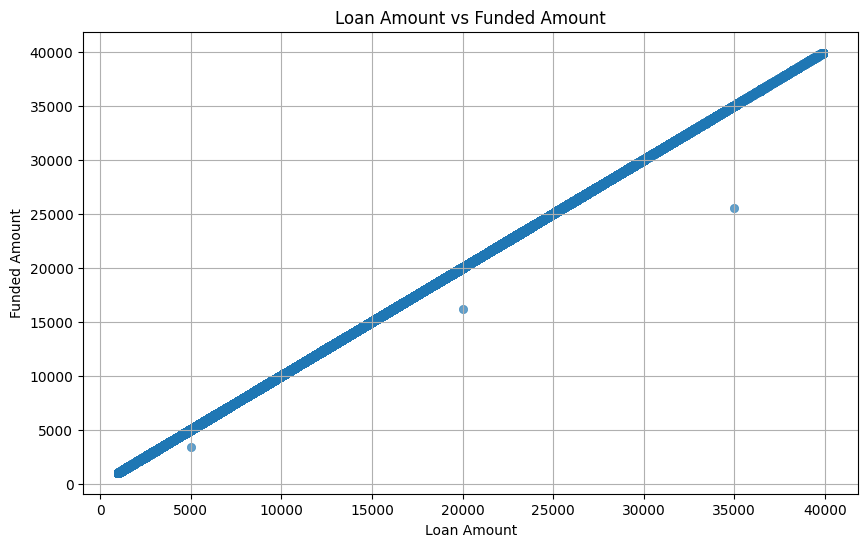

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="loan_amnt", y="funded_amnt", alpha=0.7, edgecolor=None)
plt.title("Loan Amount vs Funded Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Funded Amount")
plt.grid(True)
plt.show()

##**Trạng thái hiện tại của khoản vay**

<ipython-input-24-cf263e65309e>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="loan_status", palette="Set2")


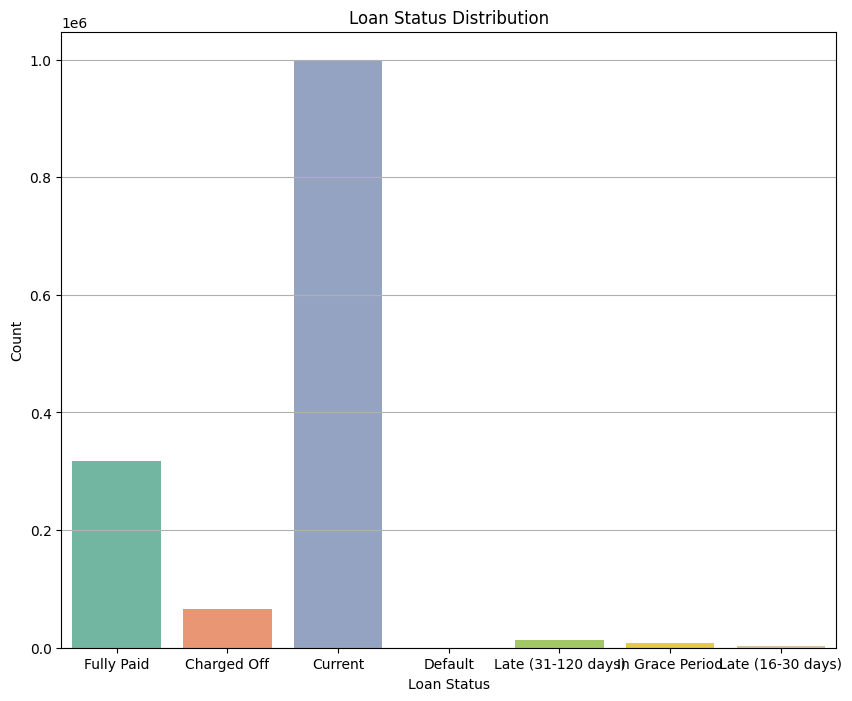

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x="loan_status", palette="Set2")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

##**Sự phân bổ của các khoản vay theo xếp hạng khoản vay**

In [ ]:
!pip install squarify

In [ ]:
import squarify

In [ ]:
grade_counts = df["grade"].value_counts()
sizes = grade_counts.values
labels = [f"{grade}: {count}" for grade, count in zip(grade_counts.index, sizes)]

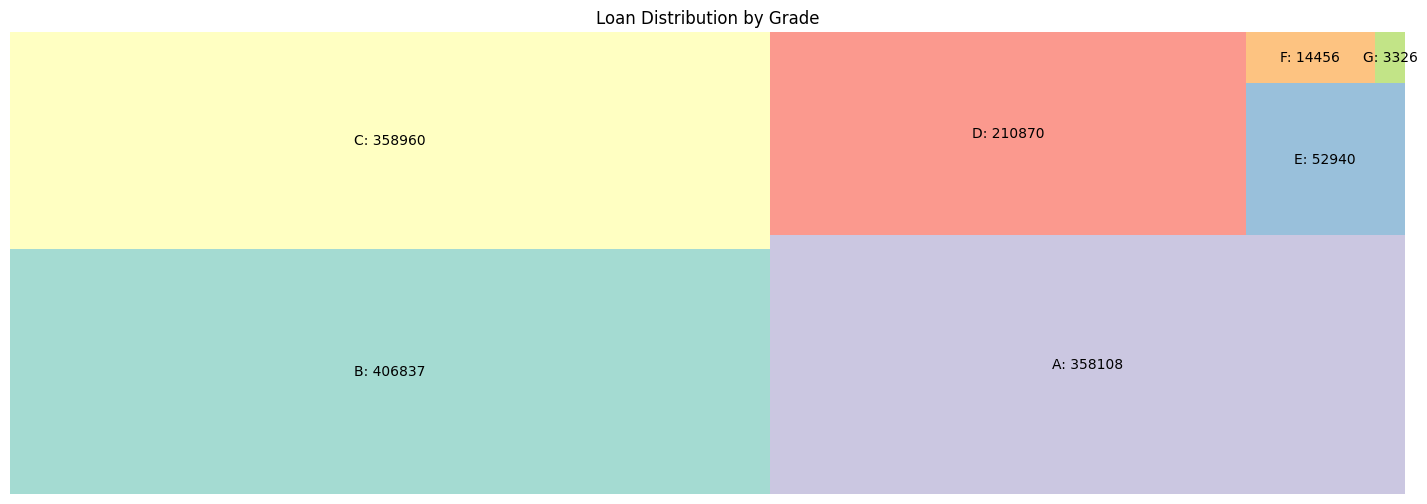

In [ ]:
plt.figure(figsize=(18, 6))
squarify.plot(sizes=sizes, label=labels, alpha=0.8, color=sns.color_palette("Set3"))
plt.title("Loan Distribution by Grade")
plt.axis("off")
plt.show()

In [ ]:
df

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,grade,home_ownership,loan_status,purpose,revol_bal,...,logunemployment,loggdppercap,muni_points,muni_6m,logCPIUS,logloan_vol,FED_lag6,riskprem,loglvol_6m,issue_year
0,11875.0,11875.0,11875.0,36 months,0.1531,C,MORTGAGE,Fully Paid,debt_consolidation,22773.0,...,10.076684,8.792181,2.494488,2.176879,5.470159,13.270999,0.11,3.207500,13.424814,2012.0
1,11500.0,11500.0,11500.0,36 months,0.1849,D,OWN,Fully Paid,debt_consolidation,11329.0,...,10.076684,8.792181,2.494488,2.176879,5.470159,13.270999,0.11,3.207500,13.424814,2012.0
2,2300.0,2300.0,2300.0,36 months,0.0890,A,RENT,Fully Paid,debt_consolidation,0.0,...,10.076684,8.792181,2.494488,2.176879,5.470159,13.270999,0.11,3.207500,13.424814,2012.0
3,19600.0,19600.0,19600.0,36 months,0.1409,B,RENT,Charged Off,major_purchase,2626.0,...,10.149370,8.812758,2.494488,2.176879,5.460810,12.277539,0.09,3.215000,13.424814,2012.0
4,3900.0,3900.0,3900.0,36 months,0.1311,B,RENT,Charged Off,debt_consolidation,5633.0,...,10.149409,8.807574,2.494488,2.176879,5.469034,12.361687,0.09,3.215000,13.424814,2012.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405492,7800.0,7800.0,7800.0,60 months,0.1612,C,RENT,Current,credit_card,5015.0,...,9.559882,6.386851,2.494488,2.119581,5.544795,16.233984,1.42,3.210833,14.128147,2019.0
1405493,3000.0,3000.0,3000.0,36 months,0.1033,B,RENT,Current,moving,21477.0,...,9.559882,6.386851,2.494488,2.119581,5.544795,16.233984,1.42,3.210833,14.128147,2019.0
1405494,7000.0,7000.0,7000.0,36 months,0.0819,A,MORTGAGE,Current,other,17625.0,...,9.559882,6.386851,2.494488,2.119581,5.544795,16.233984,1.42,3.210833,14.128147,2019.0
1405495,32000.0,32000.0,32000.0,60 months,0.1033,B,MORTGAGE,Current,credit_card,30881.0,...,9.559882,6.386851,2.494488,2.119581,5.544795,16.233984,1.42,3.210833,14.128147,2019.0
